# Métricas do sistemas
---

### Bibliotecas

---

Caso não consiga instalar execute `pip install -r requirements.txt` no terminal

In [1]:
!uv pip install -r ../requirements.txt

Using Python 3.10.11 environment at: C:\Users\Victo\Desktop\Ufal\obi-benchmarking\.venv
Checked 10 packages in 1.23s


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json

In [2]:
path_database = Path("../database")
questions_path = []
        
for folder in list(path_database.iterdir()):
    if folder.is_dir():
        questions_path.append(folder)
        
problems = []
questions_name = []
for question_path in questions_path:
    questions_name.append(question_path.name)
    
    path_imgs = question_path / "imgs"
    path_test_cases = question_path / "test_cases"
    
    if path_test_cases.exists() and path_imgs.exists():
        problems.append(json.loads(Path(question_path / "problem.json").read_text(encoding="utf-8")))
        
print(f"Quantidade de problemas com imagens: {len(problems)}")

Quantidade de problemas com imagens: 181


In [17]:
topics = []

for problem in problems:
    topics.extend(problem["topics"])
    
topicos_unicos = list(set(topics))

print(topicos_unicos)

['fenwick tree', 'componentes fortemente conexos', 'mediana', 'Programação Dinâmica', 'arredondamento', 'pilha', 'otimização', 'dfs', 'Interseção de Retângulos', 'aritmética modular', 'busca em grafos', 'array', 'permutações', 'teoria dos números', 'strings', 'implementação', 'greedy', 'dijkstra', 'Força Bruta', 'teoria dos jogos', 'lógica', 'componentes conexos', 'busca binária', 'geometria', 'contagem', 'força bruta', 'geometria computacional', 'ordenação', 'Grafos', 'árvore de fenwick', 'ad hoc', 'Geometria', 'soma de prefixos', 'vetores', 'convex hull trick', 'matemática', 'somas', 'busca em largura (bfs)', 'ad-hoc', 'Busca em Profundidade (DFS)', 'Simulação', 'two pointers', 'Matemática', 'recursão', 'matrizes', 'estruturas de dados', 'kadane', 'bfs', 'Ad-hoc', 'fórmulas', 'busca em grade', 'pré-processamento', 'busca em profundidade', 'Árvores', 'geometria espacial', 'Backtracking', 'array circular', 'sweep line', 'queries', 'flood fill', 'programação dinâmica', 'LCA', 'grafos', 

In [19]:
import pandas as pd

# Seus conjuntos de busca (já normalizados para minúsculas)
tags_grafos = {
    'grafos', 'busca em grafos', 'dfs', 'bfs', 'dijkstra', 'algoritmo de dijkstra',
    'caminho minimo', 'arvore geradora minima', 'lca', 'flood fill', 'componentes conexos',
    'componentes conexas', 'componentes fortemente conexos', 'busca em profundidade',
    'busca em largura', 'dfs/bfs', 'bfs/dfs', 'diâmetro'
}

tags_pd = {
    'programação dinâmica', 'programacao dinamica', 'pd', 'kadane', 'convex hull trick'
}

In [20]:
def contar_categorias(lista_tags):
    # Normaliza as tags da questão: remove acentos e vira minúscula
    tags_limpas = [t.lower() for t in lista_tags]
    
    # Verifica se há interseção com os grupos
    is_grafo = any(t in tags_grafos for t in tags_limpas)
    is_pd = any(t in tags_pd for t in tags_limpas)
    
    return pd.Series([is_grafo, is_pd])

# Aplicando ao seu DataFrame de questões
df[['Eh_Grafo', 'Eh_PD']] = df['tags'].apply(contar_categorias)

total_grafos = df['Eh_Grafo'].sum()
total_pd = df['Eh_PD'].sum()

print(f"Total de questões de Grafos: {total_grafos}")
print(f"Total de questões de PD: {total_pd}")

KeyError: 'tags'

In [3]:
for problem in problems:
    print(problem["title"])

Caça ao Tesouro
Gomoku
Notas da Prova
Jogo da Vida
Muro
O Chefe
Proteja sua senha
Chinelos
Jogo dos copos
Tiro ao Alvo
Robô
Transportes
Jogo de Dominós
Arco e flecha
Móbile
Campo de Minhocas
Entrega de Caixas
Cinema
Montanha
Torre
Mesa redonda
Pizzaria
Redes de Descanso
Mancha
Escher
Nova avenida
Game Show
Manchas de pele
Castelos da Nlogônia
Capitais
Quadrado Mágico
Piloto Automático
Falta uma
Palavras Cruzadas
Piso da escola
Ônibus
Chocolate em barra
Campo Minado
Fila
Jogo dos Pinos
Diagonal
Sr. Toupeira
Sr. Sapo
Duende Perdido
Bingo!
Ponto do meio
Game-10
TV da Vovó
Dança Indígena
Chuva
Dança de Formatura
Cubo Preto
Competição de chocolate
Reduzindo detalhes em um mapa
Dominó
Caminho das Pontes
Macacos me mordam!
Rodovia
VAR
Computador
Pulo do Gato
Semente
Álbum de fotos
Toca do Saci
Caminhos do reino
Cartas
Flíper
Avião
Medalhas
Elevador
Cubra os Furos
Carro elétrico
Dario e Xerxes
Quadrado Aritmético
O Tabuleiro Esburacado
Retas
Viagem
Soma
Estoque
Frete
Caçadores de Mitos
Linhas 

In [4]:
df_problems = pd.DataFrame(problems)
counts_difficulty = {}

for d in df_problems["difficulty"].unique():
    cases = df_problems[df_problems["difficulty"] == d]
    counts_difficulty[d] = len(cases)
    
print(counts_difficulty)

{'Médio': 81, 'Fácil': 67, 'Difícil': 33}


[67, 81, 33]
['Fácil', 'Médio', 'Difícil']


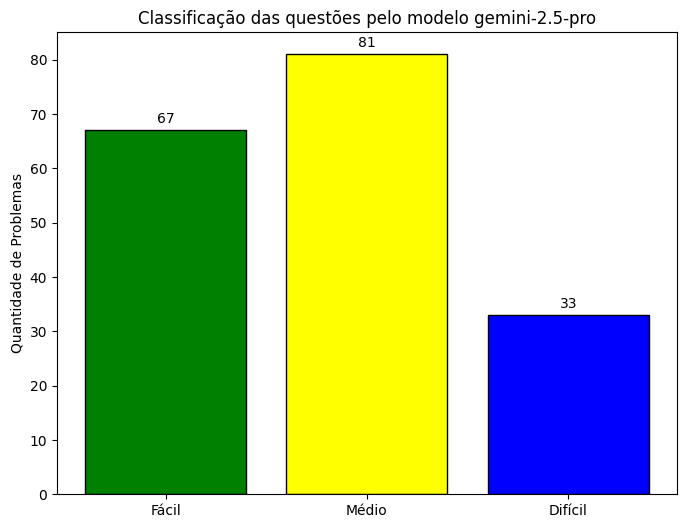

In [5]:
X = ["Fácil", "Médio", "Difícil"]
y = [counts_difficulty[x] for x in X]

print(y)
print(X)
plt.figure(figsize=(8, 6))

bar_plot = plt.bar(X, y, color=['green', 'yellow', 'blue'], edgecolor='black')

plt.bar_label(bar_plot, padding=3)

plt.title("Classificação das questões pelo modelo gemini-2.5-pro")
plt.ylabel('Quantidade de Problemas')
plt.show()

### PROMPT: QUESTÕES COM IMAGENS NA BASE64 vs QUESTÕES SEM IMAGENS
---

In [ ]:
files_path = Path("../output/cbsoft_sbes_2026/results/")
dataset = {}

count_total_tokens = {}

for path in files_path.rglob("*"):
    if not path.is_file():
        continue
    
    print()
    
    df = pd.read_csv(path)
    
    name = path.name
    count_total_tokens[name] = 0
    
    for value in df["total_tokens"]:
        count_total_tokens[name] += value
        

for key, value in count_total_tokens.items():
    print(f"file: {key} | total de tokens: {value}")



file: results_gpt_5_4_python_zero_noimg.csv| total de tokens: 203218
file: results_gpt_5_4_python_zero_img.csv| total de tokens: 240062


In [15]:
import pandas as pd
from pathlib import Path

files_path = Path("../output/cbsoft_sbes_2026/results/")
dataset = {}
configs = ['_python_zero_noimg',
           '_python_zero_img']

for config in configs:
    for path in files_path.rglob('*'):
        if not path.is_file():
            continue

        parts = str(path).split("results_")
        if len(parts) < 2:
            continue

        if not path.name.startswith("results_gpt_5_4_python"):
            continue
                
        if config not in path.name:
            continue
        
        if path.stat().st_size == 0:
            print(f"⚠️ Arquivo vazio ignorado: {path.name}")
            continue

        try:
            df = pd.read_csv(path)
            model_name = path.name.replace(".csv", "")
                    
                    
            print(model_name)
            if model_name not in dataset:
                dataset[model_name] = df
            else:
                dataset[model_name] = pd.concat([dataset[model_name], df], ignore_index=True)
        
        except ValueError as e:
            print(f"❌ Erro de ValueError (JSON malformado) no arquivo: {path.name}")
            print(f"   -> Detalhe: {e}")
        except Exception as e:
            print(f"❌ Erro inesperado ao ler {path.name}: {e}")

count = 0
for data in dataset["results_gpt_5_4_python_zero_img"]["total_test_cases"]:
    count += data

results_gpt_5_4_python_zero_noimg
results_gpt_5_4_python_zero_img


In [16]:
rows = []
for model, data in dataset.items():
    rows.append({
        "Modelo": model,
        "AC":  data["AC"].sum()  / count,
        "WA":  data["WA"].sum()  / count,
        "RE":  data["RE"].sum()  / count,
        "TLE": data["TLE"].sum() / count,
        "CE":  data["CE"].sum()  / count,
    })

df_results = pd.DataFrame(rows)

display(
    df_results.style
    .format({
        "AC":  "{:.2%}",
        "WA":  "{:.2%}",
        "RE":  "{:.2%}",
        "TLE": "{:.2%}",
        "CE":  "{:.2%}",
    })
)

,Modelo,AC,WA,RE,TLE,CE
0,results_gpt_5_4_python_zero_noimg,78.23%,19.02%,2.42%,0.33%,0.00%
1,results_gpt_5_4_python_zero_img,79.49%,17.74%,2.15%,0.62%,0.00%


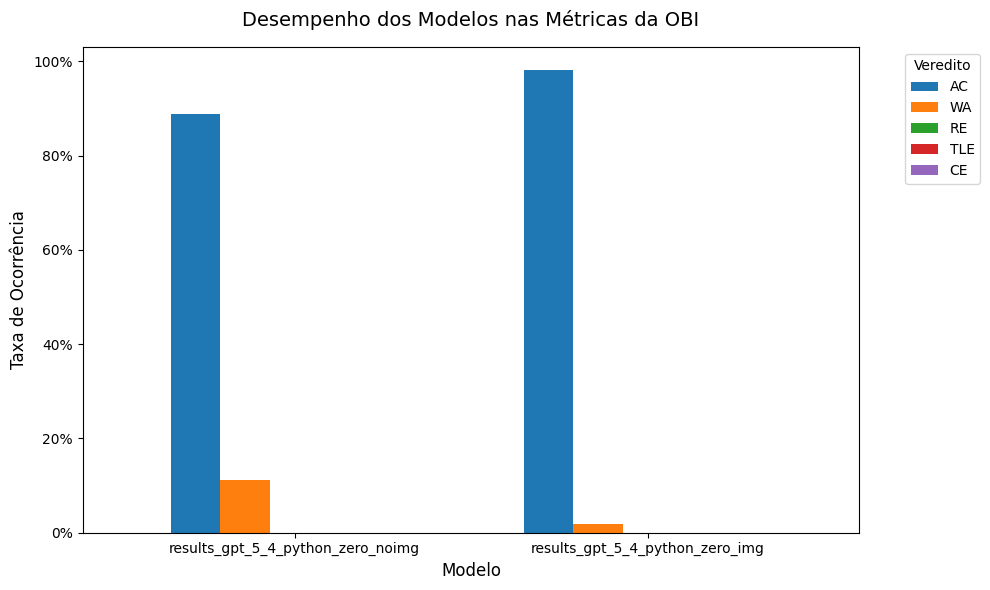

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df_plot = df_results.set_index("Modelo")

ax = df_plot.plot(kind='bar', figsize=(10, 6), width=0.7)

plt.title('Desempenho dos Modelos nas Métricas da OBI', fontsize=14, pad=15)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Taxa de Ocorrência', fontsize=12)
plt.xticks(rotation=0)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(title="Veredito", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()